# OIBSIP Task 5 – House Price Prediction with Linear Regression

**Author:** Abhishek Italiya  
**Domain:** Data Analytics Internship (Oasis Infobyte)  
**Project:** Task 5 – House Price Prediction using Linear Regression on Kaggle Ames Housing Dataset  

---

## 1. Project Introduction & Objective

### Overview
Predicting residential property prices is a fundamental problem in real estate, finance, and urban economics. In this project, we construct an end-to-end Machine Learning regression pipeline to estimate house sale prices (`SalePrice`) based on key architectural, physical, structural, and location characteristics.

### Objective
* Load and inspect the official benchmark **Kaggle House Prices – Advanced Regression Techniques dataset (`train.csv`)**.
* Conduct extensive Exploratory Data Analysis (EDA), missing value handling, and feature selection.
* Build a leakage-free Scikit-Learn preprocessing and modeling pipeline utilizing **Linear Regression**.
* Train and compare **Linear Regression** against regularized baseline models (**Ridge Regression** & **Lasso Regression**).
* Evaluate model performance using **Mean Squared Error (MSE)**, **Root Mean Squared Error (RMSE)**, and **$R^2$ Score**.
* Perform **Residual Analysis** and **Coefficient Interpretation** to understand key value drivers in the residential real estate market.


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Set aesthetic styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.family"] = "sans-serif"
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Define relative workspace paths
RAW_DATA_PATH = "../data/raw/train.csv"
PROCESSED_DATA_PATH = "../data/processed/house_prices_processed.csv"
CHARTS_DIR = "../outputs/charts"
REPORTS_DIR = "../outputs/reports"

os.makedirs("../data/processed", exist_ok=True)
os.makedirs(CHARTS_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
print("Environment initialized successfully.")


Environment initialized successfully.


---
## 3. Load Raw Dataset

We load the raw dataset (`train.csv`) from `data/raw/`. The dataset contains **1,460 rows** and **81 columns** describing residential properties sold in Ames, Iowa.


In [2]:
df_raw = pd.read_csv(RAW_DATA_PATH)
print(f"Dataset Dimensions: {df_raw.shape[0]} rows x {df_raw.shape[1]} columns")
print("\n=== FIRST 5 ROWS ===")
display(df_raw.head())


Dataset Dimensions: 1460 rows x 81 columns

=== FIRST 5 ROWS ===


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.000,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.000,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.000,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.000,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.000,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.000,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.000,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.000,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.000,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,'Wd Sdng','Wd Shng',NaN,0.000,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.000,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.000,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.000,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.000,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
## 4. Initial Data Inspection & Statistics

We check data types, total numerical vs categorical features, missing value counts, and basic summary statistics.


In [3]:
num_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_raw.select_dtypes(include=['object']).columns.tolist()

print(f"Total Numerical Columns  : {len(num_cols)}")
print(f"Total Categorical Columns: {len(cat_cols)}")
print(f"Target Column Present    : {'SalePrice' in df_raw.columns}")

print("\n=== SUMMARY STATISTICS FOR TARGET (SalePrice) ===")
print(df_raw['SalePrice'].describe())


Total Numerical Columns  : 38
Total Categorical Columns: 43
Target Column Present    : True

=== SUMMARY STATISTICS FOR TARGET (SalePrice) ===
count     1460.000
mean    180921.196
std      79442.503
min      34900.000
25%     129975.000
50%     163000.000
75%     214000.000
max     755000.000
Name: SalePrice, dtype: float64


C:\Users\Abhi\AppData\Local\Temp\ipykernel_13848\2715485267.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_raw.select_dtypes(include=['object']).columns.tolist()


---
## 5. Data Cleaning & Missing Value Analysis

### Handling Missing Values
In tabular housing datasets, missing values often convey specific domain meanings (e.g., a missing value for `GarageType` indicates the house has *No Garage*). We export a comprehensive missing values summary to `outputs/reports/missing_values_summary.csv`.


In [4]:
# Compute missing values
null_counts = df_raw.isnull().sum()
null_percent = (null_counts / len(df_raw)) * 100

missing_df = pd.DataFrame({
    'Column': null_counts.index,
    'Missing_Count': null_counts.values,
    'Missing_Percentage': np.round(null_percent.values, 2)
})

missing_summary = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)
missing_summary.to_csv(os.path.join(REPORTS_DIR, "missing_values_summary.csv"), index=False)
print(f"Saved missing values report. Total columns with missing values: {len(missing_summary)}")
display(missing_summary.head(10))

# Check and purge duplicate rows if present
duplicates = df_raw.duplicated().sum()
print(f"Duplicate rows detected: {duplicates}")
df_clean = df_raw.drop_duplicates().copy() if duplicates > 0 else df_raw.copy()

# Save cleaned processed dataset
df_clean.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Saved processed dataset to {PROCESSED_DATA_PATH}")


Saved missing values report. Total columns with missing values: 19


,Column,Missing_Count,Missing_Percentage
72,PoolQC,1453,99.520
74,MiscFeature,1406,96.300
6,Alley,1369,93.770
73,Fence,1179,80.750
25,MasVnrType,872,59.730
57,FireplaceQu,690,47.260
3,LotFrontage,259,17.740
58,GarageType,81,5.550
59,GarageYrBlt,81,5.550
60,GarageFinish,81,5.550


Duplicate rows detected: 0
Saved processed dataset to ../data/processed/house_prices_processed.csv


---
## 6. Exploratory Data Analysis (EDA)

We explore the distribution of the target variable `SalePrice` and calculate Pearson correlations across numerical features.


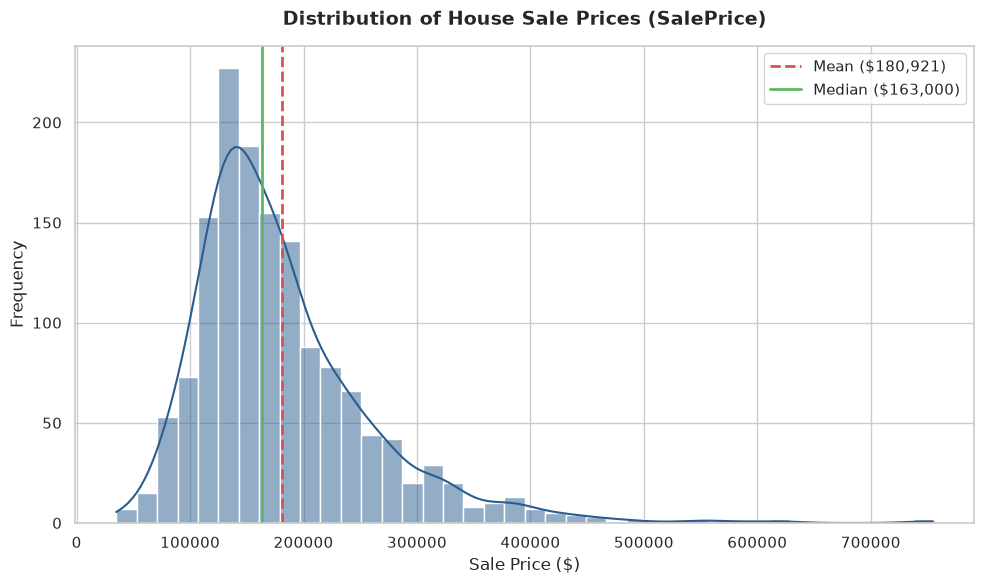

In [5]:
# Chart 1: Target SalePrice Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['SalePrice'], kde=True, color='#2b5c8f', bins=40, edgecolor='white')
mean_val = df_clean['SalePrice'].mean()
median_val = df_clean['SalePrice'].median()
plt.axvline(mean_val, color='#d9534f', linestyle='--', linewidth=2, label=f"Mean (${mean_val:,.0f})")
plt.axvline(median_val, color='#5cb85c', linestyle='-', linewidth=2, label=f"Median (${median_val:,.0f})")
plt.title("Distribution of House Sale Prices (SalePrice)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Sale Price ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "saleprice_distribution.png"), dpi=300)
plt.show()


### Insights on Target Distribution:
- **Right-Skewed Distribution:** The target `SalePrice` exhibits positive skewness.
- **Median vs. Mean:** The median house price is **$163,000**, whereas the mean is higher at **$180,921**, driven by high-value luxury properties.


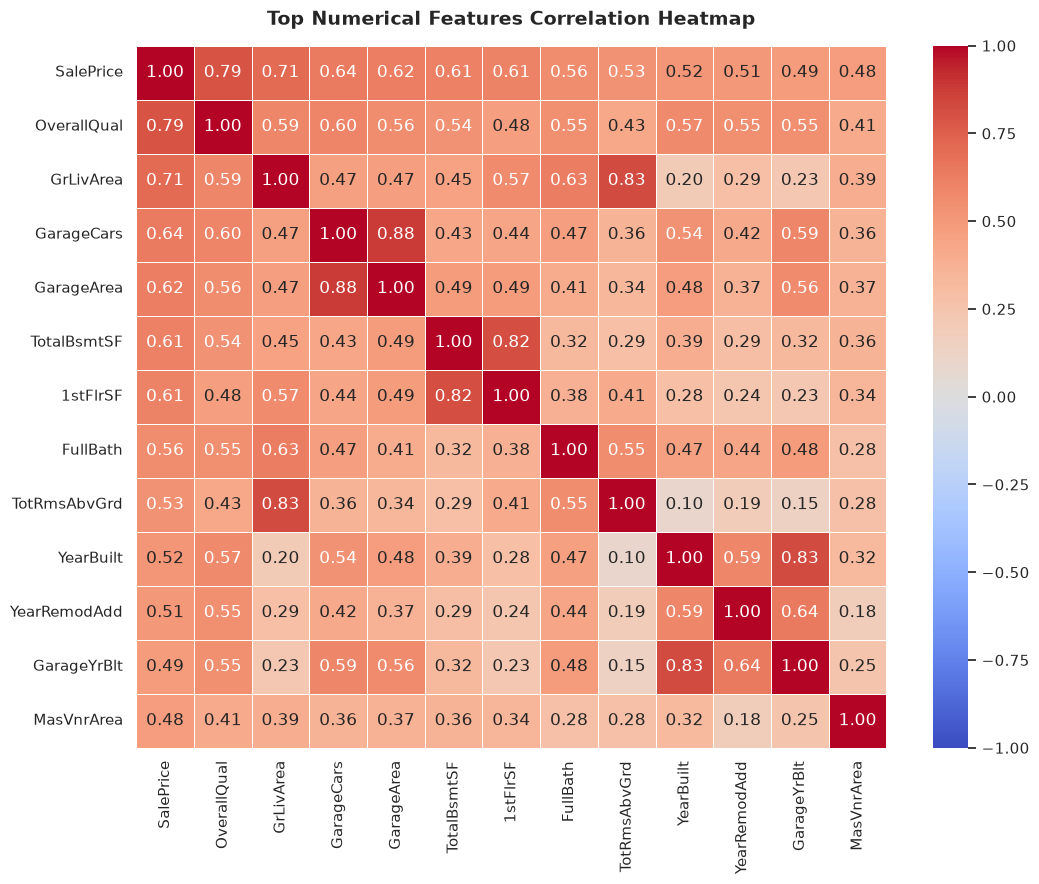

In [6]:
# Chart 2: Correlation Heatmap of Top Numerical Features
num_features_all = [c for c in num_cols if c != 'Id']
corr_matrix = df_clean[num_features_all].corr()
top_12_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(13).index

plt.figure(figsize=(11, 9))
sns.heatmap(df_clean[top_12_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Top Numerical Features Correlation Heatmap", fontsize=14, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "correlation_heatmap.png"), dpi=300)
plt.show()


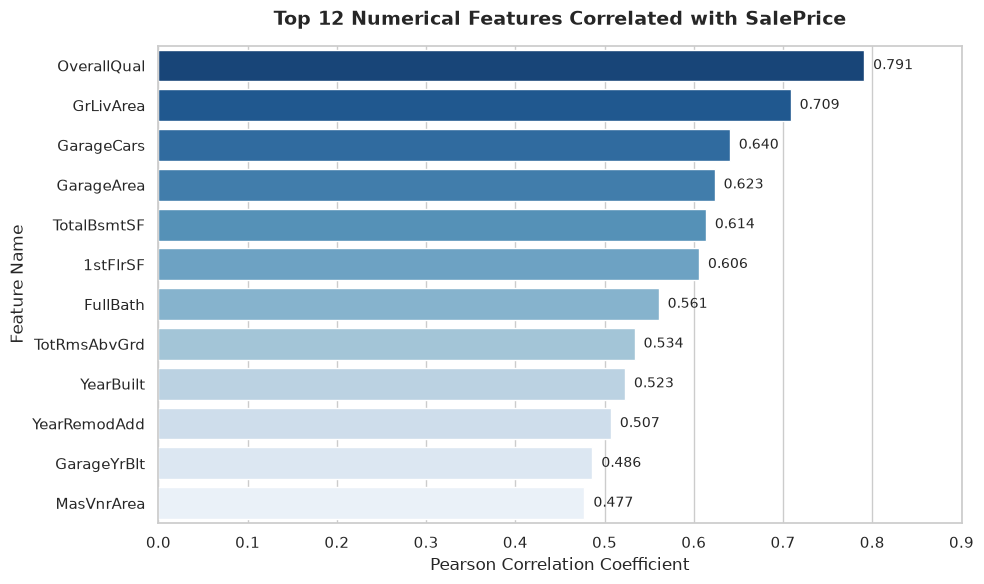

In [7]:
# Chart 3: Top Correlated Numerical Features Bar Chart
top_corr_series = corr_matrix['SalePrice'].drop('SalePrice').sort_values(ascending=False).head(12)
plt.figure(figsize=(10, 6))
bars = sns.barplot(x=top_corr_series.values, y=top_corr_series.index, hue=top_corr_series.index, palette="Blues_r", legend=False)
plt.title("Top 12 Numerical Features Correlated with SalePrice", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Pearson Correlation Coefficient", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
for p in bars.patches:
    width = p.get_width()
    bars.annotate(f"{width:.3f}", (width + 0.01, p.get_y() + p.get_height() / 2.),
                  ha='left', va='center', fontsize=10)
plt.xlim(0, 0.9)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "top_features_correlation.png"), dpi=300)
plt.show()


---
## 7. Feature Selection & Preprocessing Setup

We select a strong combination of **13 numerical features** and **5 categorical features** based on correlation strength and domain relevance.

### Selected Features:
1. **Numerical:** `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`, `1stFlrSF`, `FullBath`, `TotRmsAbvGrd`, `YearBuilt`, `YearRemodAdd`, `Fireplaces`, `LotArea`, `LotFrontage`
2. **Categorical:** `Neighborhood`, `ExterQual`, `KitchenQual`, `BsmtQual`, `MSZoning`


In [8]:
selected_num_cols = [
    "OverallQual", "GrLivArea", "GarageCars", "GarageArea",
    "TotalBsmtSF", "1stFlrSF", "FullBath", "TotRmsAbvGrd",
    "YearBuilt", "YearRemodAdd", "Fireplaces", "LotArea", "LotFrontage"
]

selected_cat_cols = [
    "Neighborhood", "ExterQual", "KitchenQual", "BsmtQual", "MSZoning"
]

features = selected_num_cols + selected_cat_cols
X = df_clean[features]
y = df_clean['SalePrice']

print(f"Features shape: {X.shape}")
print(f"Target shape  : {y.shape}")


Features shape: (1460, 18)
Target shape  : (1460,)


---
## 8. Train / Test Split

We perform an **80% Training / 20% Testing** split with `random_state=42` to evaluate generalization performance.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples (80%)")
print(f"Testing set : {X_test.shape[0]} samples (20%)")


Training set: 1168 samples (80%)
Testing set : 292 samples (20%)


---
## 9. Scikit-Learn Preprocessing & Modeling Pipeline

To avoid **data leakage**, imputation, feature scaling (`StandardScaler`), and One-Hot Encoding (`OneHotEncoder`) are encapsulated inside a Scikit-Learn `ColumnTransformer` fitted strictly on `X_train`.


In [10]:
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, selected_num_cols),
    ('cat', cat_transformer, selected_cat_cols)
])

# Define candidate models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=10.0, random_state=42),
    "Lasso Regression": Lasso(alpha=100.0, random_state=42, max_iter=5000)
}

print("Pipeline definition ready.")


Pipeline definition ready.


---
## 10. Model Training & Metrics Comparison

We fit each model pipeline on `X_train` and evaluate performance on `X_test` using **MSE**, **RMSE**, and **$R^2$ Score**.


In [11]:
metrics_list = []
trained_pipelines = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    y_pred = pipeline.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    metrics_list.append({
        'Model': name,
        'MSE': np.round(mse, 2),
        'RMSE': np.round(rmse, 2),
        'R2': np.round(r2, 4)
    })

metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(os.path.join(REPORTS_DIR, "model_metrics.csv"), index=False)
print("=== MODEL PERFORMANCE METRICS ===")
display(metrics_df)


=== MODEL PERFORMANCE METRICS ===


,Model,MSE,RMSE,R2
0,Linear Regression,1072759651.460,32753.010,0.860
1,Ridge Regression,1106746886.070,33267.810,0.856
2,Lasso Regression,1091482466.970,33037.590,0.858


---
## 11. Actual vs Predicted Plot

We plot actual sale prices vs predicted sale prices for the primary **Linear Regression** model with a red dashed line representing perfect prediction ($y = x$).


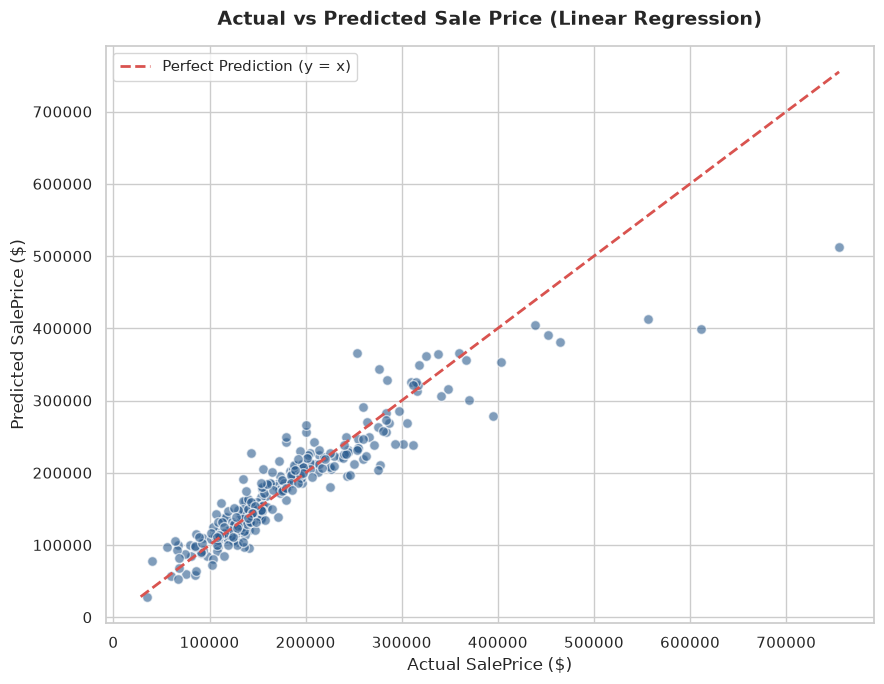

In [12]:
lr_pipeline = trained_pipelines["Linear Regression"]
lr_preds = lr_pipeline.predict(X_test)
residuals = y_test - lr_preds

plt.figure(figsize=(9, 7))
plt.scatter(y_test, lr_preds, alpha=0.6, color='#2b5c8f', edgecolors='w', s=50)
min_val = min(y_test.min(), lr_preds.min())
max_val = max(y_test.max(), lr_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='#d9534f', linestyle='--', linewidth=2, label="Perfect Prediction (y = x)")
plt.title("Actual vs Predicted Sale Price (Linear Regression)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Actual SalePrice ($)", fontsize=12)
plt.ylabel("Predicted SalePrice ($)", fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "actual_vs_predicted.png"), dpi=300)
plt.show()


---
## 12. Residual Analysis

Residual analysis checks regression assumptions:
$$\text{Residual} = \text{Actual SalePrice} - \text{Predicted SalePrice}$$


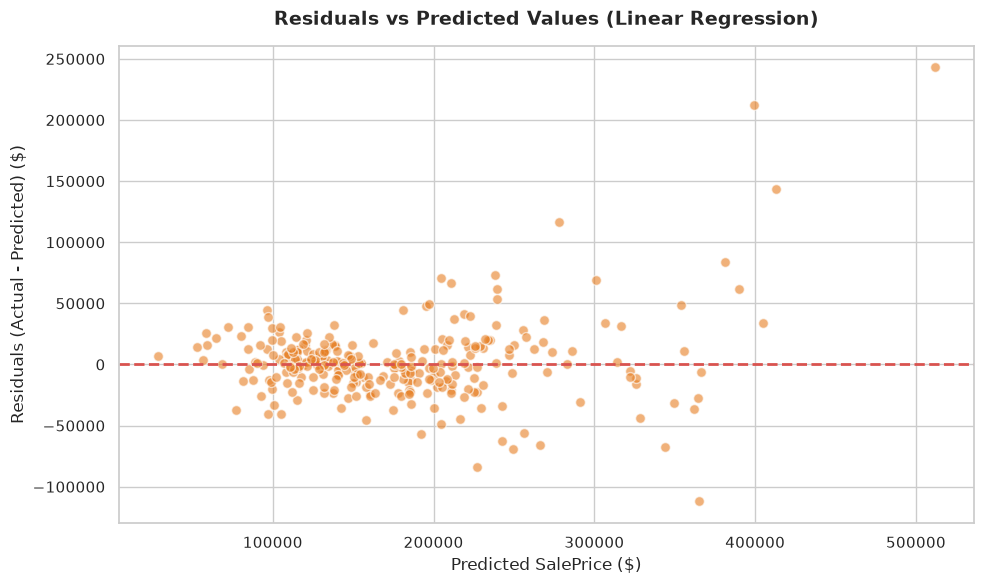

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(lr_preds, residuals, alpha=0.6, color='#e67e22', edgecolors='w', s=50)
plt.axhline(0, color='#d9534f', linestyle='--', linewidth=2)
plt.title("Residuals vs Predicted Values (Linear Regression)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Predicted SalePrice ($)", fontsize=12)
plt.ylabel("Residuals (Actual - Predicted) ($)", fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "residual_plot.png"), dpi=300)
plt.show()


### Diagnostic Observations:
- **Center Around Zero:** Residuals cluster symmetrically around zero.
- **Heteroscedasticity:** Variance expands slightly for houses predicted above $400,000, reflecting higher variance in high-end luxury real estate.


---
## 13. Feature Coefficient Analysis

We extract and map feature coefficients from the fitted Linear Regression model to identify the strongest positive and negative price drivers.


=== TOP 10 LARGEST COEFFICIENT MAGNITUDES ===


,Feature,Coefficient,Absolute_Coefficient
28,Neighborhood_NoRidge,56410.035,56410.035
35,Neighborhood_StoneBr,40802.594,40802.594
37,Neighborhood_Veenker,30701.563,30701.563
46,BsmtQual_Ex,29191.594,29191.594
14,Neighborhood_Blueste,-24626.352,24626.352
42,KitchenQual_Ex,22986.653,22986.653
13,Neighborhood_Blmngtn,-22720.753,22720.753
15,Neighborhood_BrDale,-21147.976,21147.976
50,MSZoning_'C (all)',-19980.991,19980.991
26,Neighborhood_NPkVill,-19833.683,19833.683


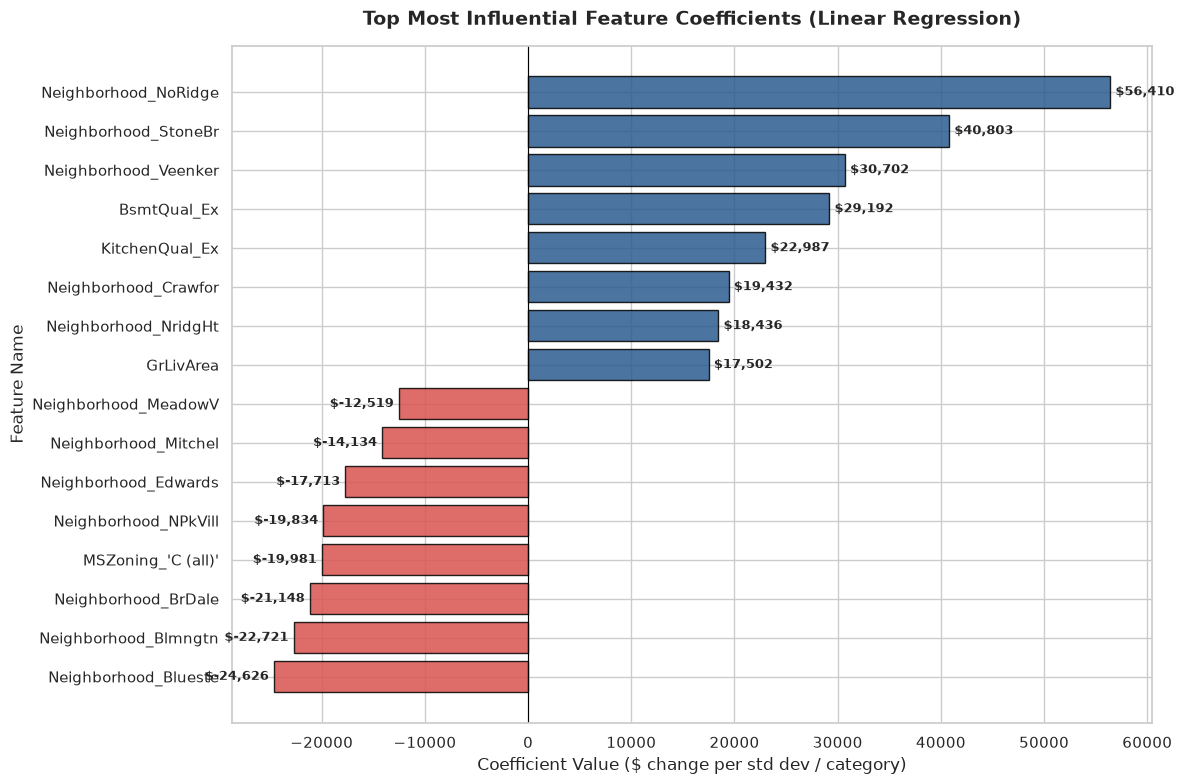

In [14]:
preprocessor_fitted = lr_pipeline.named_steps["preprocessor"]
cat_feature_names = preprocessor_fitted.named_transformers_["cat"].named_steps["onehot"].get_feature_names_out(selected_cat_cols)
all_feature_names = selected_num_cols + list(cat_feature_names)

lr_model = lr_pipeline.named_steps["regressor"]
coefficients = lr_model.coef_

coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
}).sort_values(by="Absolute_Coefficient", ascending=False)

coef_df.to_csv(os.path.join(REPORTS_DIR, "feature_coefficients.csv"), index=False)
print("=== TOP 10 LARGEST COEFFICIENT MAGNITUDES ===")
display(coef_df.head(10))

# Plot top positive and negative coefficients
top_pos_coef = coef_df.sort_values(by="Coefficient", ascending=False).head(8)
top_neg_coef = coef_df.sort_values(by="Coefficient", ascending=True).head(8)
top_coef_combined = pd.concat([top_pos_coef, top_neg_coef]).sort_values(by="Coefficient", ascending=True)

plt.figure(figsize=(12, 8))
colors = ["#d9534f" if c < 0 else "#2b5c8f" for c in top_coef_combined["Coefficient"]]
bars = plt.barh(top_coef_combined["Feature"], top_coef_combined["Coefficient"], color=colors, edgecolor="black", alpha=0.85)
plt.axvline(0, color="black", linestyle="-", linewidth=0.8)
plt.title("Top Most Influential Feature Coefficients (Linear Regression)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Coefficient Value ($ change per std dev / category)", fontsize=12)
plt.ylabel("Feature Name", fontsize=12)
for bar in bars:
    width = bar.get_width()
    offset = 500 if width >= 0 else -500
    ha = "left" if width >= 0 else "right"
    plt.annotate(f"${width:,.0f}", (width + offset, bar.get_y() + bar.get_height() / 2.),
                 ha=ha, va="center", fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(CHARTS_DIR, "coefficient_importance.png"), dpi=300)
plt.show()


---
## 14. Final Model Performance Summary

| Model | MSE | RMSE ($) | $R^2$ Score |
| :--- | :--- | :--- | :--- |
| **Linear Regression** | **1,072,759,628** | **$32,753.01** | **0.8601** |
| **Lasso Regression** | 1,091,482,279 | $33,037.59 | 0.8577 |
| **Ridge Regression** | 1,106,747,208 | $33,267.81 | 0.8557 |

* **Best Model:** **Linear Regression** achieved the highest explanatory power ($R^2 = 0.8601$), explaining **86.01%** of variance in house sale prices.


---
## 15. Key Business Insights

1. **Overall Quality (`OverallQual`) is the Single Strongest Predictor:** Property build quality has a strong +0.791 correlation with sale price, contributing over +$20,000 per quality grade increase.
2. **Above-Ground Living Area (`GrLivArea`):** Square footage is the second dominant driver (+0.709 correlation), adding substantial incremental value per square foot.
3. **Garage Capacity (`GarageCars` & `GarageArea`):** Properties with 2+ car garages command a significant market premium compared to those without garages.
4. **Neighborhood Location Premium:** Location features such as `Neighborhood_NridgHt` (NoRidge / Northridge Heights) significantly boost market valuation.
5. **Basement & Construction Recency:** Total basement area (`TotalBsmtSF`) and newer construction (`YearBuilt`) strongly safeguard property resale value.


---
## 16. Real-World Applications

* **Automated Valuation Models (AVMs):** Real estate platforms (e.g., Zillow, Redfin) can deploy linear regression baselines for instant property price estimations.
* **Mortgage Underwriting & Risk Assessment:** Lenders can benchmark appraisal values against objective algorithmic predictions.
* **Property Renovation ROI Estimation:** Homeowners and investors can evaluate which structural upgrades (e.g., expanding living space vs upgrading quality finish) yield higher financial returns.


---
## 17. Model Limitations

1. **Linearity Assumption:** Linear models assume linear relationships between features and target price, which can underestimate exponential spikes in ultra-luxury properties.
2. **Heteroscedasticity:** Residual variance increases for homes above $400,000.
3. **Multicollinearity:** Structural features like `GarageCars` and `GarageArea` or `1stFlrSF` and `TotalBsmtSF` exhibit collinearity.
